# EDA Титаника

Этот ноутбук — аналитическое дополнение к Titanic-пайплайну.
Он проверяет основные распределения, пропуски и простые сильные сигналы до обучения моделей.

## Что здесь проверяем

- Насколько таргет несбалансирован и какие группы реально отличаются по выживаемости.
- Какие признаки дают самый ясный сигнал без сложной модели: `Sex`, `Pclass`, `TitleClean`, `FamilySize`, `IsChild`.
- Где в данных много пропусков и почему это важно до обучения модели.

Смысл этого EDA не в красивых картинках, а в том, чтобы увидеть, какие простые гипотезы уже объясняют большую часть поведения данных.

In [10]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Works both when the notebook is launched from project root or from notebooks/
candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidate_roots if (p / "data" / "train.csv").exists()), None)
if project_root is None:
    raise FileNotFoundError(
        "Не найден data/train.csv. Откройте ноутбук из папки проекта или проверьте структуру data/."
    )

data_dir = project_root / "data"
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")

for df in (train, test):
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False).fillna("Unknown")
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df["IsChild"] = (df["Age"] < 16).astype(int)
    df["TicketGroupSize"] = df.groupby("Ticket")["Ticket"].transform("count")

rare_titles = set(train["Title"].value_counts()[train["Title"].value_counts() < 10].index)
for df in (train, test):
    df["TitleClean"] = df["Title"].replace({t: "Rare" for t in rare_titles})

print(f"Текущая рабочая папка: {Path.cwd()}")
print(f"Используемая папка данных: {data_dir}")

display(train.head())
print(f"Форма train: {train.shape}")
print(f"Форма test: {test.shape}")
print(f"Доля выживших в train: {train['Survived'].mean():.3f}")

Текущая рабочая папка: /home/pavel/titanic_project/notebooks
Используемая папка данных: /home/pavel/titanic_project/data


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,IsChild,TicketGroupSize,TitleClean
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,0,1,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,0,1,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,0,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,0,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,0,1,Mr


Форма train: (891, 18)
Форма test: (418, 17)
Доля выживших в train: 0.384


In [ ]:
missing = train.isna().mean().sort_values(ascending=False).head(10)

survival_by_title = (
    train.groupby("TitleClean", as_index=False)["Survived"]
    .agg(["mean", "count"])
    .reset_index()
    .query("count >= 10")
    .sort_values(["mean", "count"], ascending=[False, False])
    .head(10)
 )

print("Топ пропусков в train:")
display(missing.rename("missing_share").to_frame())
print("Какие титулы дают самый заметный сигнал:")
display(survival_by_title)
print("Какие группы семей по размеру слишком редкие и могут шуметь:")
display(train.groupby("FamilySize")["Survived"].agg(["mean", "count"]).query("count < 10"))

### Что видно сразу

- Пол и класс дают самый очевидный разделяющий сигнал: это не «магия модели», а просто сильная структура в данных.
- Титулы помогают понять статус пассажира и часто объясняют выживаемость лучше, чем просто имя или возраст.
- Очень маленькие семейные группы шумные, поэтому для них нельзя делать слишком уверенные выводы без проверки количества наблюдений.

Дальше я смотрю не на абстрактные метрики, а на конкретные группы людей и на то, как они пересекаются между собой.

,feature,best_group,best_group_survival_rate
0,Sex,female,0.742038
1,Pclass,1,0.629630
2,IsChild,1,0.590361
3,IsAlone,0,0.505650
4,Embarked,C,0.553571


,TitleClean,mean,count
3,Mrs,0.792000,125
1,Miss,0.697802,182
0,Master,0.575000,40
4,Rare,0.444444,27
2,Mr,0.156673,517


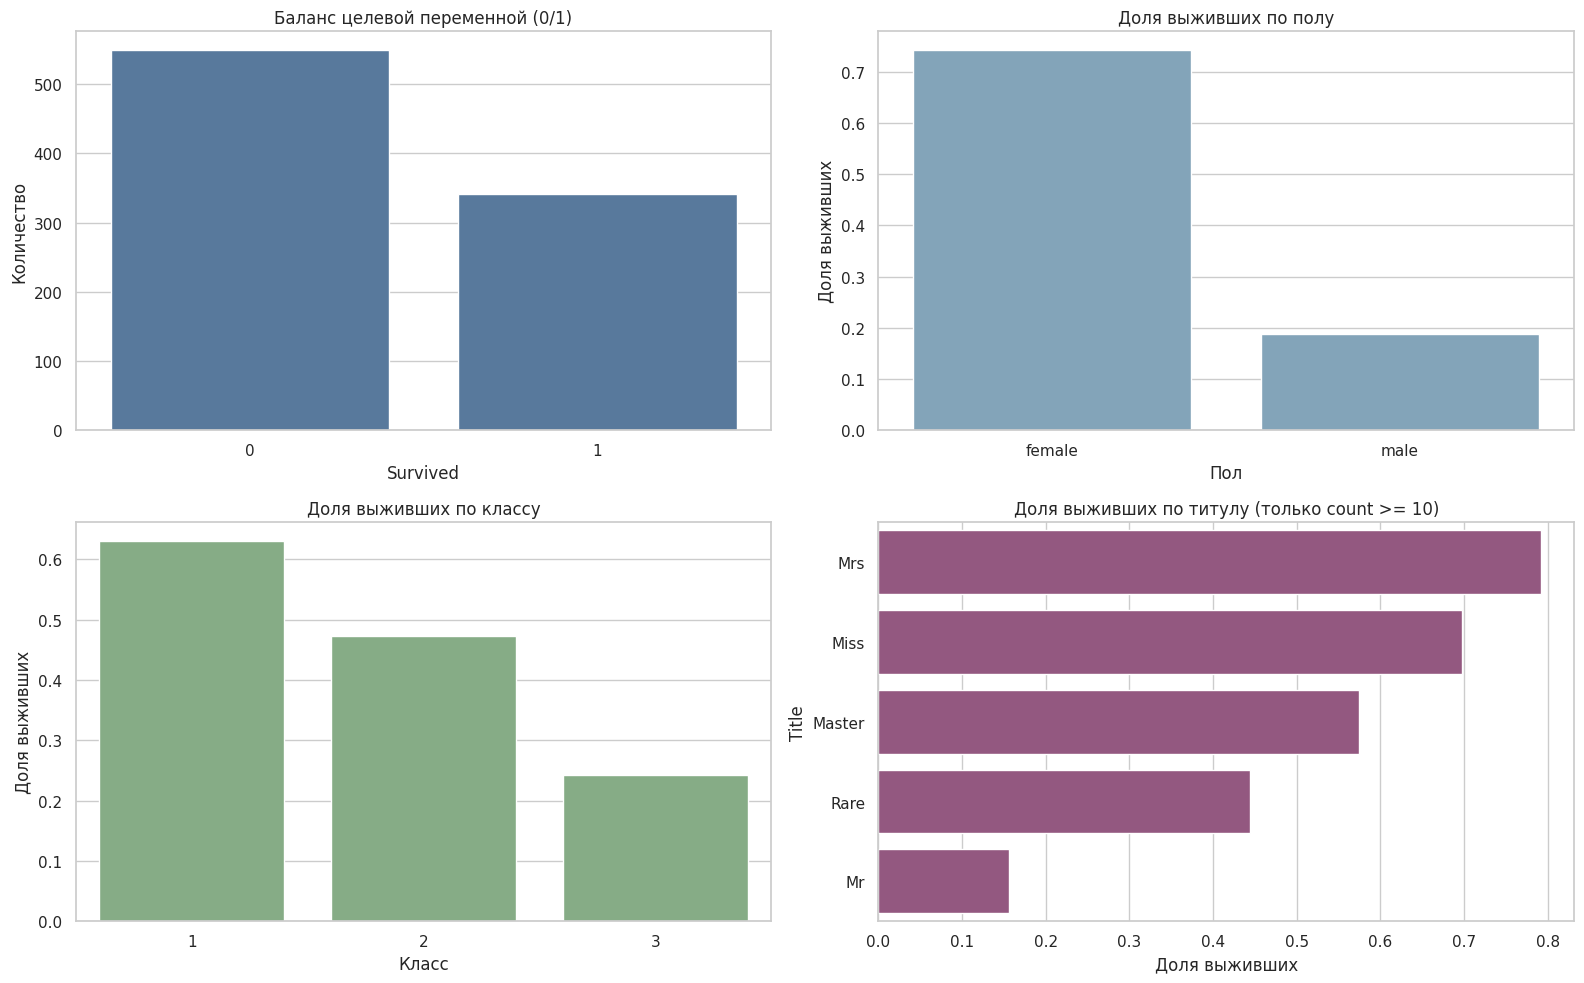

In [11]:
# 1) Базовый баланс таргета и самые важные категориальные сигналы
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

surv_counts = train["Survived"].value_counts().sort_index()
sns.barplot(x=surv_counts.index, y=surv_counts.values, ax=axes[0, 0], color="#4c78a8")
axes[0, 0].set_title("Баланс целевой переменной (0/1)")
axes[0, 0].set_xlabel("Survived")
axes[0, 0].set_ylabel("Количество")

sex_rate = train.groupby("Sex", as_index=False)["Survived"].mean().sort_values("Survived", ascending=False)
sns.barplot(data=sex_rate, x="Sex", y="Survived", ax=axes[0, 1], color="#7aa6c2")
axes[0, 1].set_title("Доля выживших по полу")
axes[0, 1].set_xlabel("Пол")
axes[0, 1].set_ylabel("Доля выживших")

class_rate = train.groupby("Pclass", as_index=False)["Survived"].mean().sort_values("Pclass")
sns.barplot(data=class_rate, x="Pclass", y="Survived", ax=axes[1, 0], color="#7fb37f")
axes[1, 0].set_title("Доля выживших по классу")
axes[1, 0].set_xlabel("Класс")
axes[1, 0].set_ylabel("Доля выживших")

title_stats = train.groupby("TitleClean")["Survived"].agg(["mean", "count"]).reset_index()
title_rate = title_stats.query("count >= 10").sort_values("mean", ascending=False).head(10)
sns.barplot(data=title_rate, y="TitleClean", x="mean", ax=axes[1, 1], color="#9d4e84")
axes[1, 1].set_title("Доля выживших по титулу (только count >= 10)")
axes[1, 1].set_xlabel("Доля выживших")
axes[1, 1].set_ylabel("Title")

plt.tight_layout()

# Короткая таблица для быстрых выводов
key_table = pd.DataFrame({
    "feature": ["Sex", "Pclass", "IsChild", "IsAlone", "Embarked"],
    "best_group": [
        train.groupby("Sex")["Survived"].mean().idxmax(),
        train.groupby("Pclass")["Survived"].mean().idxmax(),
        int(train.groupby("IsChild")["Survived"].mean().idxmax()),
        int(train.groupby("IsAlone")["Survived"].mean().idxmax()),
        train.groupby("Embarked")["Survived"].mean().idxmax(),
    ],
    "best_group_survival_rate": [
        train.groupby("Sex")["Survived"].mean().max(),
        train.groupby("Pclass")["Survived"].mean().max(),
        train.groupby("IsChild")["Survived"].mean().max(),
        train.groupby("IsAlone")["Survived"].mean().max(),
        train.groupby("Embarked")["Survived"].mean().max(),
    ],
})
display(key_table)
display(title_stats.sort_values(["mean", "count"], ascending=[False, False]).head(10))

,abs_corr_with_survived
Pclass,0.338481
Fare,0.257307
IsAlone,0.203367
IsChild,0.136107
Parch,0.081629
Age,0.077221
TicketGroupSize,0.038247
SibSp,0.035322
FamilySize,0.016639


Редкие группы FamilySize (count < 10), где оценка может быть шумной:


,FamilySize,mean,count
7,8,0.0,6
8,11,0.0,7


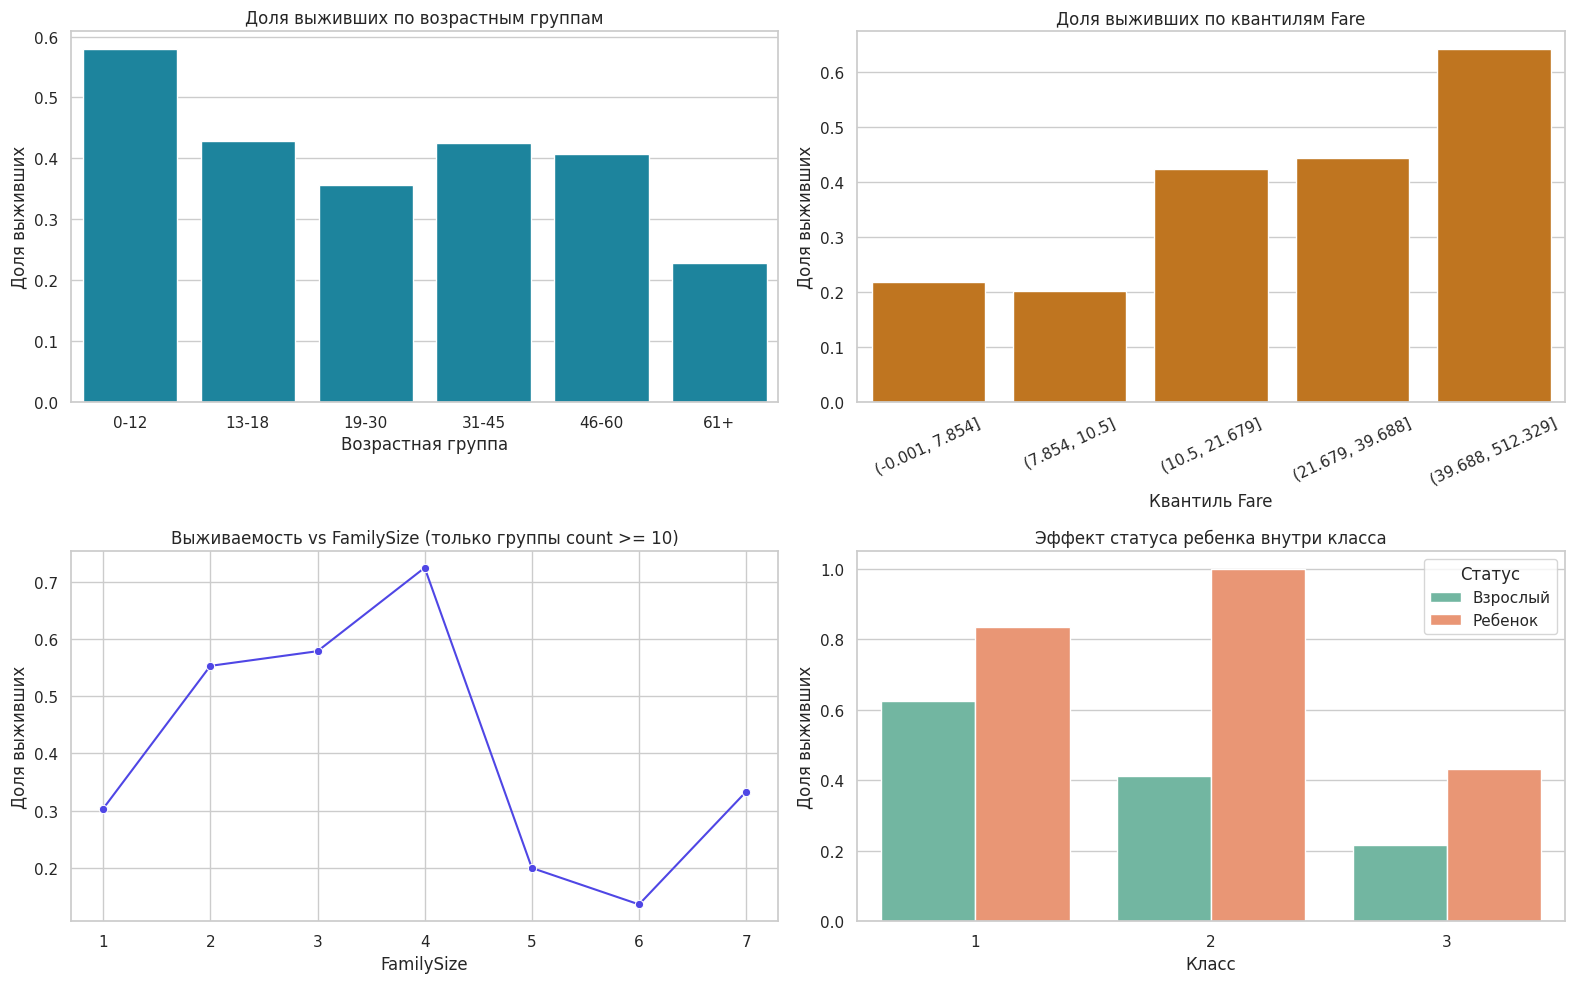

In [12]:
# 2) Возраст/стоимость/семейный контекст: где реально виден сигнал
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

age_view = train.dropna(subset=["Age"]).copy()
age_view["AgeBand"] = pd.cut(
    age_view["Age"],
    bins=[0, 12, 18, 30, 45, 60, 80],
    labels=["0-12", "13-18", "19-30", "31-45", "46-60", "61+"],
    include_lowest=True,
)
age_rate = age_view.groupby("AgeBand", as_index=False, observed=False)["Survived"].mean()
sns.barplot(data=age_rate, x="AgeBand", y="Survived", ax=axes[0, 0], color="#0891b2")
axes[0, 0].set_title("Доля выживших по возрастным группам")
axes[0, 0].set_xlabel("Возрастная группа")
axes[0, 0].set_ylabel("Доля выживших")

fare_view = train.copy()
fare_view["FareFilled"] = fare_view["Fare"].fillna(fare_view["Fare"].median())
fare_view["FareBand"] = pd.qcut(fare_view["FareFilled"], q=5, duplicates="drop")
fare_rate = fare_view.groupby("FareBand", as_index=False, observed=False)["Survived"].mean()
sns.barplot(data=fare_rate, x="FareBand", y="Survived", ax=axes[0, 1], color="#d97706")
axes[0, 1].set_title("Доля выживших по квантилям Fare")
axes[0, 1].set_xlabel("Квантиль Fare")
axes[0, 1].set_ylabel("Доля выживших")
axes[0, 1].tick_params(axis="x", rotation=25)

family_stats = train.groupby("FamilySize")["Survived"].agg(["mean", "count"]).reset_index()
family_rate = family_stats.query("count >= 10")
sns.lineplot(data=family_rate, x="FamilySize", y="mean", marker="o", ax=axes[1, 0], color="#4f46e5")
axes[1, 0].set_title("Выживаемость vs FamilySize (только группы count >= 10)")
axes[1, 0].set_xlabel("FamilySize")
axes[1, 0].set_ylabel("Доля выживших")

child_class = train.groupby(["IsChild", "Pclass"], as_index=False)["Survived"].mean()
child_class["IsChildLabel"] = child_class["IsChild"].map({0: "Взрослый", 1: "Ребенок"})
sns.barplot(data=child_class, x="Pclass", y="Survived", hue="IsChildLabel", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Эффект статуса ребенка внутри класса")
axes[1, 1].set_xlabel("Класс")
axes[1, 1].set_ylabel("Доля выживших")
axes[1, 1].legend(title="Статус")

plt.tight_layout()

# Топ фичей по силе связи с таргетом (без сложных моделей)
num_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "IsChild", "TicketGroupSize"]
corr_abs = train[num_cols + ["Survived"]].corr(numeric_only=True)["Survived"].drop("Survived").abs().sort_values(ascending=False)
display(corr_abs.rename("abs_corr_with_survived").to_frame())

print("Редкие группы FamilySize (count < 10), где оценка может быть шумной:")
display(family_stats.query("count < 10").sort_values("FamilySize"))

## Короткие выводы

- Самые сильные простые сигналы — пол, класс и семейный контекст пассажира.
- Возраст и стоимость билета полезны, но сами по себе менее устойчивы, чем сочетание категориальных признаков.
- Пропуски сосредоточены неравномерно, поэтому для части признаков важно аккуратное заполнение, а не удаление.

Этот ноутбук специально компактный, но он уже документирует первые гипотезы и форму данных перед моделированием.